In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


# We will be tackling the Credit Card Fraud Detection dataset:
# We will be predicting if transaction was fraudulent or not, and target is severly imbalanced
# We only have 492 frauds in 284,807 transactions.

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud


In [4]:
# Getting the data
import os
print(os.listdir(path))

['creditcard.csv']


In [5]:
import pandas as pd

# Create full file path
file_path = os.path.join(path, 'creditcard.csv')

# Load into a DataFrame
df = pd.read_csv(file_path)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Print whole dataset
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


We will seperate the X and y

In [7]:
X = df.drop(columns=['Class'])
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00


In [8]:
y = df['Class']
y

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64

In [9]:
# Investigating the X data
X.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000


In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

No NAN values and all values are float64, so no need for imputer or OHE

In [11]:
X.value_counts()

Time      V1          V2          V3         V4         V5         V6         V7          V8          V9         V10        V11        V12        V13        V14        V15        V16        V17        V18        V19        V20        V21         V22        V23        V24        V25        V26        V27        V28        Amount
163152.0  -1.203617    1.574009    2.889277   3.381404   1.538663   3.698747   0.560211   -0.150911    0.124136   4.220998   1.384569  -0.706897  -0.256274  -1.562583   1.692915  -0.787338  -0.226776  -0.412354   0.234322   1.385597  -0.366727    0.522223  -0.357329  -0.870174  -0.134166   0.327019  -0.042648  -0.855262  1.51      18
          -1.196037    1.585949    2.883976   3.378471   1.511706   3.717077   0.585362   -0.156001    0.122648   4.217934   1.385525  -0.709405  -0.256168  -1.564352   1.693218  -0.785210  -0.228008  -0.412833   0.234834   1.375790  -0.370294    0.524395  -0.355170  -0.869790  -0.133198   0.327804  -0.035702  -0.858197  7.56      1

In [12]:
# Checking the target class now, y
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 284807 entries, 0 to 284806
Series name: Class
Non-Null Count   Dtype
--------------   -----
284807 non-null  int64
dtypes: int64(1)
memory usage: 2.2 MB


In [13]:
y.describe()

count    284807.000000
mean          0.001727
std           0.041527
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Class, dtype: float64

In [14]:
y.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

# Splitting Data into Train, Val, and Test sets

In [15]:
from sklearn.model_selection import train_test_split

# WE dont include testing sets here cause we will split again later for Validation and Test sets
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42)

# Now split for Validation and Test sets
X_val, X_test, y_val, y_test = train_test_split(X_train, y_train, test_size=0.4, stratify=y_train, shuffle=True, random_state=42)

In [16]:
X_val.shape

(136707, 30)

In [17]:
X_test.shape

(91138, 30)

In [18]:
y_test.value_counts()

Class
0    90980
1      158
Name: count, dtype: int64

In [19]:
y_val.value_counts()

Class
0    136471
1       236
Name: count, dtype: int64

# We will now perform both Feature extraction and selection to reduce number of features.

In [20]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Now we are going to select only the top 10 most important features using SelectKBest and also Feature importances from RFR

In [21]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestRegressor

Find corr matrix on only a random subset of Train set to make calculations quicker

In [22]:
# Calculate length of data
data_length = X_train.shape[0]


indices = np.random.choice(data_length, size=20_000, replace=False)
X_subsample = X_train.iloc[indices]
y_subsample = y_train.iloc[indices]

In [23]:
# Fit the selector on the subsample of data to find the top 10 most important features
selector = SelectKBest(score_func=mutual_info_classif, k=10)
selector_fitted = selector.fit_transform(X_subsample, y_subsample)

In [24]:
# Getting Boolean array of which features were in top 10
selector_features = selector.get_support()

In [25]:
# Extracting only top 10 features from X_train
top_10 = X_train.columns[selector_features]
top_10

Index(['V3', 'V4', 'V7', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17'], dtype='object')

In [26]:
# Finding the scores for each of the top 10 features
scores_10 = selector.scores_
scores_10[selector_features].reshape(1,-1)

array([[0.00452689, 0.00418461, 0.00292036, 0.00317343, 0.00683192,
        0.00548247, 0.00581264, 0.00621997, 0.0038968 , 0.00625451]])

In [27]:
top_10_df = pd.DataFrame(scores_10[selector_features], index=top_10, columns=['Score']).sort_values(by='Score', ascending=False)
top_10_df

,Score
V10,0.006832
V17,0.006255
V14,0.006220
V12,0.005813
V11,0.005482
V3,0.004527
V4,0.004185
V16,0.003897
V9,0.003173
V7,0.002920


In [28]:
top_10_corr = pd.DataFrame(scores_10[selector_features].reshape(1,-1), columns=top_10)
top_10_corr

,V3,V4,V7,V9,V10,V11,V12,V14,V16,V17
0,0.004527,0.004185,0.00292,0.003173,0.006832,0.005482,0.005813,0.00622,0.003897,0.006255


In [29]:
top_10_corr.isnull()

,V3,V4,V7,V9,V10,V11,V12,V14,V16,V17
0,False,False,False,False,False,False,False,False,False,False


Now calculating the Corr matrix for these top 10 features to see how correlated they are both with each other and also to the target

In [30]:
# Now that we have the subsample, we will perform the corr matrix to see how closely features are correlated
corr = top_10_corr.corr()
corr

,V3,V4,V7,V9,V10,V11,V12,V14,V16,V17
V3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
scores_10

array([1.18068792e-03, 9.99752369e-04, 2.67727394e-03, 4.52689382e-03,
       4.18461171e-03, 1.78838915e-03, 1.93957367e-03, 2.92035914e-03,
       9.97982175e-04, 3.17343357e-03, 6.83191955e-03, 5.48246811e-03,
       5.81264176e-03, 0.00000000e+00, 6.21996931e-03, 2.89641240e-04,
       3.89679753e-03, 6.25451245e-03, 2.47922555e-03, 6.93452584e-04,
       1.07627426e-03, 6.71417873e-04, 4.54770636e-04, 1.29103208e-04,
       0.00000000e+00, 8.60455439e-05, 2.97770387e-04, 1.07943167e-03,
       6.54500848e-04, 8.42894470e-04])

In [32]:
new_df = X_subsample.columns[selector_features]
new_df = X_subsample[new_df]
new_df

,V3,V4,V7,V9,V10,V11,V12,V14,V16,V17
31832,2.585283,-1.464800,-0.171285,-0.248554,-0.297205,1.489570,0.425660,-1.228075,-0.337398,1.442687
273345,-1.114617,-0.107374,-0.138444,0.252916,0.215877,0.859987,1.004070,0.448612,0.718936,-0.970667
66890,1.011550,0.724721,0.225086,-0.955985,-0.139767,0.836052,0.814739,0.690522,0.191032,-0.443227
244235,-1.068244,-1.226403,-1.187590,0.017679,0.903354,-0.158993,-0.461626,-0.249863,1.658323,-0.444586
146809,-0.211014,-1.862211,0.486297,1.391914,-0.543708,-0.208841,-0.047872,-0.817829,1.015643,-1.306686
...,...,...,...,...,...,...,...,...,...,...
13175,0.338118,1.078566,0.065254,2.137085,-1.049478,2.205805,-1.345040,1.428493,-0.370845,1.224829
67349,0.033493,-3.229288,3.058836,3.493880,-0.482623,-0.808241,0.015067,-1.708998,-0.239297,-1.630221
274580,-1.155306,-1.519753,0.808153,0.578446,-0.858611,0.346557,-0.363751,-2.037911,-0.157861,0.766162
132923,-0.301966,0.097504,0.495172,0.010142,-0.198075,-0.662483,-0.107426,0.514232,0.302538,-0.354185


In [33]:
new_df.describe()

,V3,V4,V7,V9,V10,V11,V12,V14,V16,V17
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.002160,-0.002624,0.005166,0.001853,-0.000415,0.008631,-0.003486,0.009269,0.002794,0.009765
std,1.499082,1.416087,1.226141,1.098134,1.087849,1.012645,0.993149,0.950453,0.868475,0.816802
min,-22.338591,-5.401678,-33.239328,-10.842526,-19.836149,-4.682931,-17.003289,-14.094452,-12.661696,-20.164542
25%,-0.904884,-0.846446,-0.544317,-0.643619,-0.537981,-0.752429,-0.410999,-0.423025,-0.473819,-0.475104
50%,0.173469,-0.028975,0.042851,-0.054326,-0.097058,-0.003343,0.141148,0.056346,0.066898,-0.057483
75%,1.035549,0.734678,0.574014,0.602760,0.447818,0.747220,0.621205,0.508595,0.530344,0.412119
max,4.017561,12.699542,28.504065,9.272376,13.249433,9.939820,4.072078,6.684591,5.600123,7.733456


# Plotting the Corr matrix for the Df with only the top 10 features

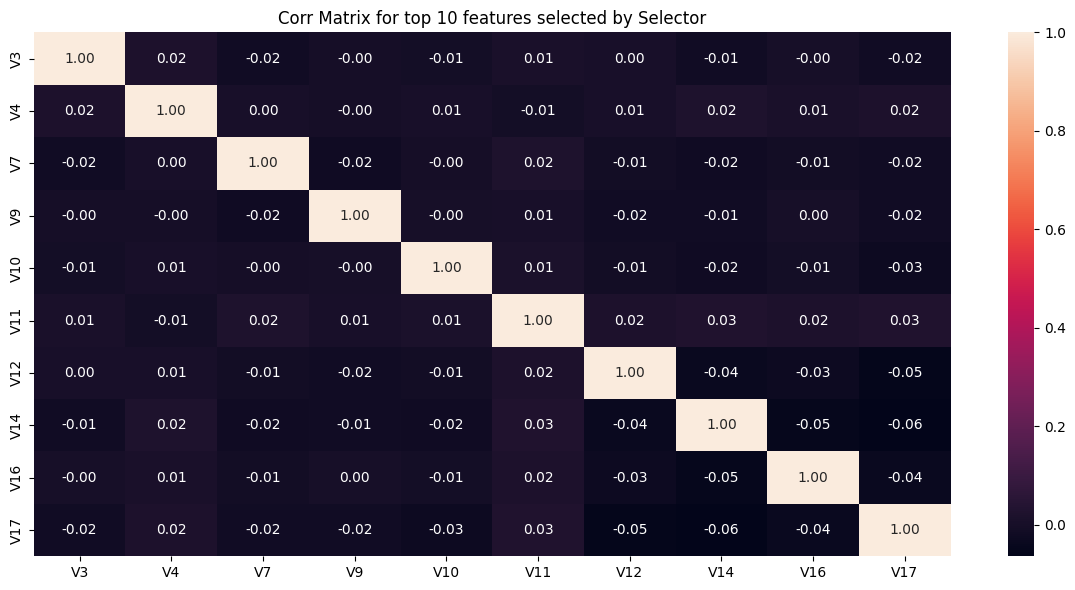

In [34]:
import seaborn as sns

plt.figure(figsize=(12,6))

# Plot Heatmap, use annot=True so we can see the values, and cbar=True so we can see the colorbar
sns.heatmap(new_df.corr(), annot=True, cbar=True, fmt='.2f')
plt.title('Corr Matrix for top 10 features selected by Selector')
plt.tight_layout()
plt.show()

In [35]:
new_df.shape

(20000, 10)

In [36]:
y_subsample.value_counts()

Class
0    19970
1       30
Name: count, dtype: int64

# Find the correlations with thee target variable for our top 10 features
# We use abs to find the absolute value, only measuring distance

In [37]:
correlations = new_df.corrwith(y_subsample)

In [38]:
# Find the Absolute Value
corr_abs = correlations.abs().sort_values(ascending=False)

In [39]:
corr_abs

V17    0.274800
V14    0.257484
V12    0.229739
V10    0.209198
V3     0.194702
V7     0.162136
V16    0.154360
V11    0.131439
V4     0.120330
V9     0.091990
dtype: float64

# Now i am going to use a baseline tree model to get the baseline score the advanced model needs to beat
# We will also check it on the full dataset with all of the features to see if reducing the amount of features helped model with its predictions

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
all_rfr = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
top_10_rfr = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

In [42]:
all_rfr.fit(X_subsample, y_subsample)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [43]:
# new df is the New Dataframe only consisting fo top 10 features
top_10_rfr.fit(new_df, y_subsample)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [44]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score, ConfusionMatrixDisplay, f1_score, recall_score, precision_score
from sklearn.model_selection import cross_val_score, KFold

Getting the predictions for our model

In [45]:
k = KFold(n_splits=5, shuffle=True, random_state=42)

all_scores = cross_val_score(all_rfr, X_subsample, y_subsample, cv=k, scoring='balanced_accuracy', n_jobs=-1)

In [46]:
top_10_scores = cross_val_score(top_10_rfr, new_df, y_subsample, cv=k, scoring='balanced_accuracy', n_jobs=-1)

In [47]:
# Viewing the scores for all features and top 10 selected features

all_scores

array([0.83320824, 0.5625    , 0.78571429, 0.78571429, 0.79987484])

In [48]:
top_10_scores

array([0.83320824, 0.5625    , 0.92857143, 0.78558907, 0.89987484])

In [49]:
print(f'Mean Score with all Features: {all_scores.mean()}')
print(f'Mean Score with Top 10 Features: {top_10_scores.mean()}')

Mean Score with all Features: 0.7534023308991965
Mean Score with Top 10 Features: 0.8019487156439282


In [50]:
y_subsample_df = pd.DataFrame(y_subsample)
y_subsample_df

,Class
31832,0
273345,0
66890,0
244235,0
146809,0
...,...
13175,0
67349,0
274580,0
132923,0


# Clearly, using only the top 10 features is much better than using all of the features, so we will only use it from now on

# Since running any code with over 100k instances takes forever, we will use NearMiss, an undersampling technique used to reduce the number of obvious Not Fraud datapoints, and only keep the ones that are on the border of Fraud and Not Fraud. 
# It used KNN under the hood to measure the distance from all of the 'Normal' datapoints to all of the target datapoints, and only selects the oens that are closest to the target instances, deleting everything else.

In [51]:
from imblearn.under_sampling import NearMiss

# Initialize NearMiss
# verison=1: This selects sampels with the smallest avg distance to the closest minority samples
# sampling_strategy=0.1: This will reduce majority class until it is only 10x the size of the target or minority class
# (eg. If you have 492 Fraud, you will end up with around 4920 Not Fraud)
near_miss = NearMiss(version=1, sampling_strategy=0.01)

# Perform the reduction 
X_resampled, y_resampled = near_miss.fit_resample(X_train, y_train)

In [52]:
print(f'X_train Shape: {X_train.shape}')
print(f'X_resampled Shape: {X_resampled.shape}')

X_train Shape: (227845, 30)
X_resampled Shape: (39794, 30)


In [53]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

In [54]:
y_resampled.value_counts()

Class
0    39400
1      394
Name: count, dtype: int64

In [55]:
top_10

Index(['V3', 'V4', 'V7', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17'], dtype='object')

In [56]:
X_resampled

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,76866.0,1.257227,0.408096,0.319266,0.685011,-0.302937,-1.052552,0.136991,-0.245655,-0.079491,...,-0.033053,-0.279430,-0.770134,0.119789,0.360130,0.241921,0.092261,-0.018228,0.032361,1.78
1,76868.0,1.254775,0.375340,0.311959,0.691077,-0.343494,-1.065252,0.110222,-0.222721,-0.017278,...,-0.057911,-0.283275,-0.803506,0.124643,0.354395,0.226835,0.093208,-0.021100,0.031686,2.69
2,76870.0,-1.050697,1.500753,0.846326,-0.282956,0.059866,-0.561182,0.484517,0.181547,0.081544,...,0.457988,-0.335560,-0.780232,-0.027029,-0.090180,-0.022896,0.091830,0.547241,0.278780,1.29
3,76866.0,1.245537,0.419648,0.312943,1.111459,-0.205612,-0.950912,0.267398,-0.274685,-0.127708,...,-0.098066,0.035687,0.186705,-0.107300,0.417887,0.712330,-0.330843,0.018576,0.021871,3.99
4,76870.0,1.261137,0.304662,0.527018,0.612765,-0.411488,-0.972770,0.112838,-0.248052,-0.068454,...,-0.044989,-0.249081,-0.683649,0.126936,0.395307,0.243448,0.092344,-0.024149,0.020589,1.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39789,143354.0,1.118331,2.074439,-3.837518,5.448060,0.071816,-1.020509,-1.808574,0.521744,-2.032638,...,0.163513,0.289861,-0.172718,-0.021910,-0.376560,0.192817,0.114107,0.500996,0.259533,1.00
39790,30852.0,-2.830984,0.885657,1.199930,2.861292,0.321669,0.289966,1.767760,-2.451050,0.069736,...,-1.016923,0.546589,0.334971,0.172106,0.623590,-0.527114,-0.079215,-2.532445,0.311177,104.81
39791,160034.0,-2.349340,1.512604,-2.647497,1.753792,0.406328,-2.188494,-0.686935,-0.547984,-0.099528,...,-0.093421,-0.088519,-0.595178,0.258148,0.061901,-0.354180,-1.152671,-0.736073,0.733703,4.90
39792,94364.0,-15.192064,10.432528,-19.629515,8.046075,-12.838167,-1.875859,-21.359738,-3.717850,-5.969782,...,1.657476,-3.474097,1.765446,1.701257,0.381587,-1.413417,-1.023078,-2.634761,-0.463931,1.00


# Now we split into Train/Test again with the new, resampled data

In [57]:
from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_resampled[X_resampled.columns[selector_features]], y_resampled, test_size=0.2, stratify=y_resampled, random_state=42, shuffle=True)

In [58]:
X_train_new.shape

(31835, 10)

In [59]:
X_test_new.shape

(7959, 10)

In [60]:
X_train_new

,V3,V4,V7,V9,V10,V11,V12,V14,V16,V17
8045,0.533396,0.012368,-2.200350,-1.422534,0.754861,0.845748,-1.459026,-0.332673,0.815476,1.386193
9057,2.480536,0.183970,-0.900708,0.295856,-0.830759,1.172723,1.182710,-0.277440,-1.029644,0.596880
39257,1.093189,2.500989,-0.122534,-0.669722,0.628482,-0.361262,0.630635,-0.216158,0.867512,-0.843063
32800,0.861649,-2.471848,0.351239,1.745705,-1.306398,0.066147,0.972351,-0.267342,-1.424331,-0.179389
28096,2.620217,1.532845,0.217221,0.697459,0.132714,0.646351,1.002448,-0.979039,-1.597852,0.683185
...,...,...,...,...,...,...,...,...,...,...
25732,1.308421,-3.023316,-1.022058,1.549008,-2.485723,-0.074279,1.106228,0.003064,-1.402457,0.247331
1339,-1.179153,-4.759357,-0.332189,1.164751,-2.832865,-0.650286,0.916144,0.756747,-0.165214,-0.606929
32039,-1.081145,-0.624437,-0.948110,1.128801,-0.019879,0.718637,0.140405,0.419962,0.208369,-0.177746
31295,-0.913255,0.515121,0.111437,0.660899,0.093366,-0.489391,0.070982,0.501748,-0.238043,-0.025347


In [61]:
y_test_new.value_counts()

Class
0    7880
1      79
Name: count, dtype: int64

# We now use an RFR model to get base prediction of model before using SMOTE

In [62]:
rfr = RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced')

In [63]:
rfr.fit(X_train_new, y_train_new)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [64]:
predict_rfr = rfr.predict(X_test_new)

In [65]:
predict_rfr

array([0, 0, 0, ..., 0, 0, 0])

Compute the Balanced Accuracy as well as Precision & Recall

In [66]:
balanced_acc = balanced_accuracy_score(y_test_new, predict_rfr)
precision_rfr = precision_score(y_test_new, predict_rfr)
recall_rfr = recall_score(y_test_new, predict_rfr)

In [67]:
print(f'Balanced ACC: {balanced_acc}')
print(f'Precision ACC: {precision_rfr}')
print(f'Recall ACC: {recall_rfr}')

Balanced ACC: 0.8924050632911392
Precision ACC: 1.0
Recall ACC: 0.7848101265822784


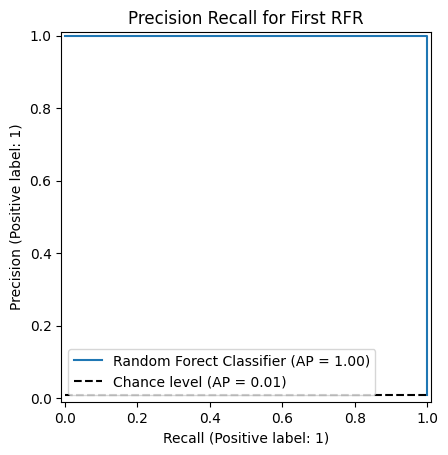

In [68]:
from sklearn.metrics import PrecisionRecallDisplay

disp = PrecisionRecallDisplay.from_estimator(
    rfr,
    X_train_new,
    y_train_new,
    name='Random Forect Classifier',
    plot_chance_level=True
)


_ = disp.ax_.set_title('Precision Recall for First RFR')
plt.show()

# The plot above, even though it looks perfect, since ensemble methods are memorizing machines, it perfectly memorized the trianing examples we gave it during fitting. To actually see its generalization power, we will feed it to the testing set.

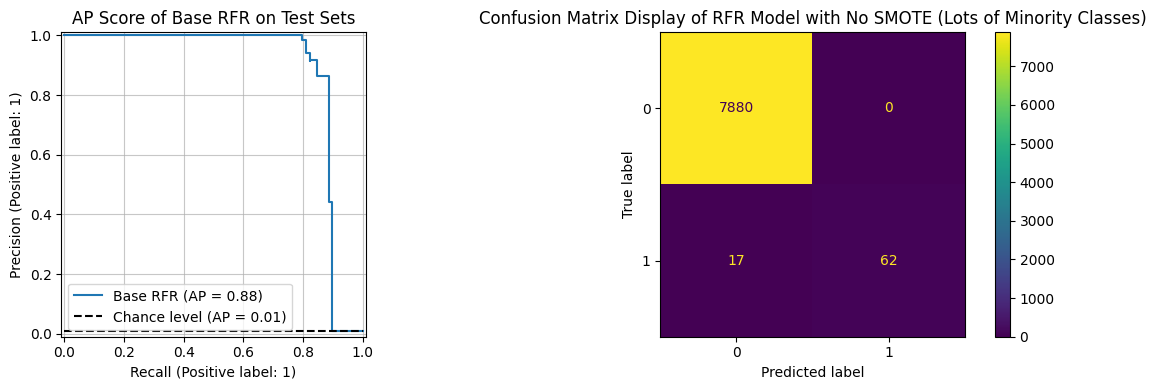

In [69]:
# Now plot it again, but this time using Test sets
from sklearn.metrics import ConfusionMatrixDisplay


fig, ax = plt.subplots(1,2, figsize=(12,4))

new_disp = PrecisionRecallDisplay.from_estimator(
    rfr,
    X_test_new,
    y_test_new,
    name='Base RFR',
    plot_chance_level=True,
    ax=ax[0]
)

cm = ConfusionMatrixDisplay.from_estimator(
    rfr,
    X_test_new,
    y_test_new,
    ax=ax[1]
)



ax[0].set_title('AP Score of Base RFR on Test Sets')
ax[0].grid(axis='both', alpha=0.7)

ax[1].set_title('Confusion Matrix Display of RFR Model with No SMOTE (Lots of Minority Classes)')
plt.tight_layout()
plt.show()

Now we are going to check the F1 score

In [70]:
f1_score_rfr = f1_score(y_test_new, predict_rfr)
print(f'F1 Score for Base RFR: {f1_score_rfr}')

F1 Score for Base RFR: 0.8794326241134752


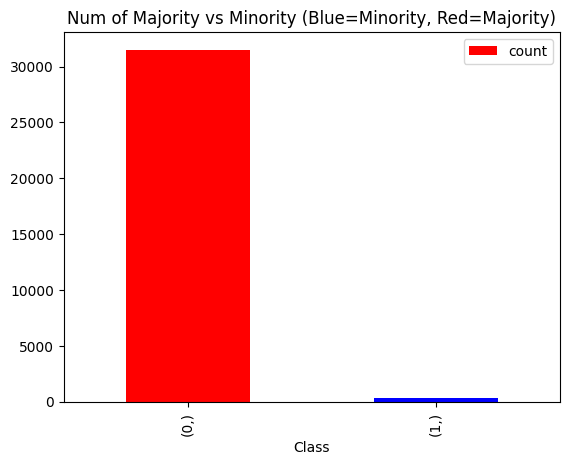

In [71]:
y_train_new_df = pd.DataFrame(y_train_new)
y_train_new_df.value_counts().plot(kind='bar', color=['red', 'blue'])
plt.title('Num of Majority vs Minority (Blue=Minority, Red=Majority)')
plt.legend()
plt.show()

In [72]:
last_rfr = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

In [73]:
y_train_new_df

,Class
8045,0
9057,0
39257,0
32800,0
28096,0
...,...
25732,0
1339,0
32039,0
31295,0


# WE are now going to use over_samplign with SMOTE to see if it increases model F1/AP scores

In [74]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# configure the Forger
# sampling_strategy=0.5: Means Create Fake data until Fraud is 50% the size of Normal
smote = SMOTE(sampling_strategy=0.5, random_state=42)


# Build the Leak-Proof Pipeline
# Ensures that SMOTE only runs on the training data during and fit() or cross_validation
smote_pipeline = Pipeline([
    ('smote', smote),
    ('model', last_rfr)
])

# Fit the pipeline
# Under the hood this SMOTE's the training data, then fits the RandomForest
smote_pipeline.fit(X_train_new, y_train_new)

Pipeline(steps=[('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
                ('model',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [75]:
# Predict on the completely unseen Test set

smote_predict = smote_pipeline.predict(X_test_new)

In [76]:
smote_predict.shape

(7959,)

In [77]:
y_test_new.shape

(7959,)

# Plotting the PR Curve and ConfusionMatrixDisplay

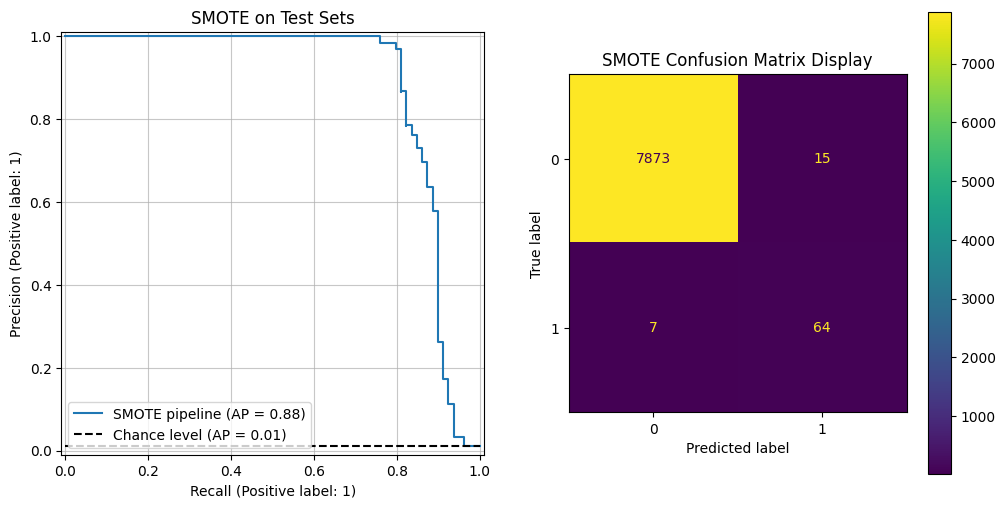

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1,2, figsize=(12,6))

# Plot the PrecisionRecallDisplay On the Left
disp = PrecisionRecallDisplay.from_estimator(
    smote_pipeline,
    X_test_new,
    y_test_new,
    name='SMOTE pipeline',
    plot_chance_level=True,
    ax=ax[0]
)


# Plot the ConfusionMatrixDisplay on the right

disp_c = ConfusionMatrixDisplay.from_predictions(
    smote_predict,
    y_test_new,
    ax=ax[1]
)




ax[0].set_title('SMOTE on Test Sets')
ax[0].grid(axis='both', alpha=0.7)

ax[1].set_title('SMOTE Confusion Matrix Display')
plt.show()

# Viewing the Size of the new Test Data

In [79]:
# To view the 'Magic' under the hood, we have to manually run SMOTE again on data
X_train_smote, y_train_smote = smote.fit_resample(X_train_new, y_train_new)

In [80]:
y_train_smote.value_counts()

Class
0    31520
1    15760
Name: count, dtype: int64

In [81]:
X_train_smote

,V3,V4,V7,V9,V10,V11,V12,V14,V16,V17
0,0.533396,0.012368,-2.200350,-1.422534,0.754861,0.845748,-1.459026,-0.332673,0.815476,1.386193
1,2.480536,0.183970,-0.900708,0.295856,-0.830759,1.172723,1.182710,-0.277440,-1.029644,0.596880
2,1.093189,2.500989,-0.122534,-0.669722,0.628482,-0.361262,0.630635,-0.216158,0.867512,-0.843063
3,0.861649,-2.471848,0.351239,1.745705,-1.306398,0.066147,0.972351,-0.267342,-1.424331,-0.179389
4,2.620217,1.532845,0.217221,0.697459,0.132714,0.646351,1.002448,-0.979039,-1.597852,0.683185
...,...,...,...,...,...,...,...,...,...,...
47275,0.280994,0.287408,0.546947,-0.492332,0.362510,-1.224328,0.016771,-0.314871,-1.094367,-0.278346
47276,1.256314,1.453129,1.212917,-0.600056,-0.159645,-0.708967,-0.583174,-0.220395,-0.245746,0.074314
47277,-6.780631,2.217761,-1.030439,-2.126533,-6.105978,2.277858,-5.798782,-7.004490,-4.506939,-5.533969
47278,-2.113306,4.194368,0.622835,-1.534533,0.239536,1.614250,-0.004034,-2.885420,1.783836,1.789631


# Now we view the new, SMOTE'd testing set with half the size of the OG majority class

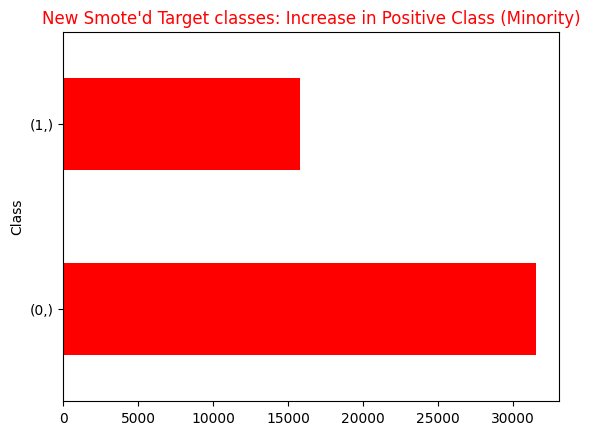

In [82]:
# Turning it into DF
y_train_smote_df = pd.DataFrame(y_train_smote)

# Plotting the Value counts
y_train_smote_df.value_counts().plot(kind='barh', color='red')
plt.title("New Smote'd Target classes: Increase in Positive Class (Minority)", color='red')
plt.show()

In [83]:
print(f'BALANCED ACC WITHOUT SMOTE: {balanced_accuracy_score(y_test_new, predict_rfr)}') #
print(f'BALANCED ACC WITH SMOTE: {balanced_accuracy_score(y_test_new, smote_predict)}') 
print(f'F1 SCORE WITHOUT SMOTE: {f1_score(y_test_new, predict_rfr)}')#
print(f'F1 SCORE WITH SMOTE: {f1_score(y_test_new, smote_predict)}')
print(f'PRECISION SCORE WITHOUT SMOTE: {precision_score(y_test_new, predict_rfr)}')#
print(f'PRECISION SCORE WITH SMOTE: {precision_score(y_test_new, smote_predict)}')
print(f'RECALL SCORE WITHOUT SMOTE: {recall_score(y_test_new, predict_rfr)}')#
print(f'RECALL SCORE WITH SMOTE: {recall_score(y_test_new, smote_predict)}')

BALANCED ACC WITHOUT SMOTE: 0.8924050632911392
BALANCED ACC WITH SMOTE: 0.9046191287026923
F1 SCORE WITHOUT SMOTE: 0.8794326241134752
F1 SCORE WITH SMOTE: 0.8533333333333334
PRECISION SCORE WITHOUT SMOTE: 1.0
PRECISION SCORE WITH SMOTE: 0.9014084507042254
RECALL SCORE WITHOUT SMOTE: 0.7848101265822784
RECALL SCORE WITH SMOTE: 0.810126582278481


# We are now going to find the optimal threshoold value that maximizes the F1 score:
# We will use precision_recall_curve, since it return the threshold varibale, indicating the threshold values in which model score imporoved
# FOR SMOTE PIPELINE:
#       We will test non-smote pipeline later to check if SMOTE is worth it

In [84]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# We first need the prediction of the SMOTE PIPELINE
# We use [:,1], so that we get probas of Positive Class (Minority Class)
smote_probas = smote_pipeline.predict_proba(X_test_new)[:,1]

# Now we use the smote_probas in precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test_new, smote_probas)

# Now we calculate the F1 Score of each of the Threshold values
f1 = 2 * (precision * recall) / (precision + recall)

# find index of highest F1 Score
best_indx = np.argmax(f1)
best_thresh = thresholds[best_indx]
best_f1 = f1[best_indx]

In [85]:
best_indx

np.int64(48)

In [86]:
best_f1

np.float64(0.8827586206896552)

In [87]:
best_thresh

np.float64(0.72)

In [88]:
f1

array([0.01965663, 0.06121627, 0.10678211, 0.15529906, 0.20054201,
       0.24914676, 0.29258517, 0.33488372, 0.37402597, 0.40793201,
       0.43292683, 0.46864686, 0.49477352, 0.52398524, 0.5546875 ,
       0.56349206, 0.58677686, 0.60425532, 0.62555066, 0.64545455,
       0.66046512, 0.67942584, 0.7029703 , 0.71428571, 0.72164948,
       0.72916667, 0.74074074, 0.74594595, 0.76243094, 0.7752809 ,
       0.77272727, 0.77714286, 0.7816092 , 0.79069767, 0.79289941,
       0.80239521, 0.8       , 0.80487805, 0.80981595, 0.80246914,
       0.80745342, 0.82802548, 0.83870968, 0.84415584, 0.83660131,
       0.85333333, 0.8590604 , 0.8707483 , 0.88275862, 0.875     ,
       0.88111888, 0.87323944, 0.86524823, 0.85714286, 0.86330935,
       0.85507246, 0.84671533, 0.83823529, 0.82962963, 0.82089552,
       0.81203008, 0.8030303 , 0.78461538, 0.765625  , 0.        ])

# Now, since we found out that the optimal threshold is 0.69, we will compute the new predictions manually with the new threshold

In [89]:
smote_new_probas = smote_pipeline.predict_proba(X_test_new)[:,1]

# Adding the custom threshold to the model
custom_pred = (smote_new_probas >= best_thresh).astype(int)

In [90]:
custom_pred_1 =pd.DataFrame(custom_pred)
custom_pred_1.value_counts()

0
0    7893
1      66
Name: count, dtype: int64

In [91]:
thresh_normal = (smote_new_probas >= 0.5).astype(int)
thresh_normal_df = pd.DataFrame(thresh_normal)
thresh_normal_df.value_counts()

0
0    7885
1      74
Name: count, dtype: int64

# Now we compute metrics to see if model is performing better

In [92]:
print(f"BALANCED ACC SCORE FOR CUSTOM THRESH SMOTE PIPELINE: {balanced_accuracy_score(y_test_new, custom_pred)}")
print(f"PRECISION SCORE FOR CUSTOM THRESH SMOTE PIPELINE: {precision_score(y_test_new, custom_pred)}")
print(f"RECALL SCORE FOR CUSTOM THRESH SMOTE PIPELINE: {recall_score(y_test_new, custom_pred)}")
print(f"F1 SCORE FOR CUSTOM THRESH SMOTE PIPELINE: {f1_score(y_test_new, custom_pred)}")


BALANCED ACC SCORE FOR CUSTOM THRESH SMOTE PIPELINE: 0.9049363875859411
PRECISION SCORE FOR CUSTOM THRESH SMOTE PIPELINE: 0.9696969696969697
RECALL SCORE FOR CUSTOM THRESH SMOTE PIPELINE: 0.810126582278481
F1 SCORE FOR CUSTOM THRESH SMOTE PIPELINE: 0.8827586206896552


In [93]:
print(f"BALANCED ACC SCORE FOR RFR: {balanced_accuracy_score(y_test_new, custom_pred)}")


BALANCED ACC SCORE FOR RFR: 0.9049363875859411


# For NON-SMOTE:

In [94]:
rfr_probas = rfr.predict_proba(X_test_new)[:,1]

prec, rec, thresh = precision_recall_curve(y_test_new, rfr_probas)

rfr_f1 = 2 * (prec * rec) / (prec + rec)

best_rfr_indx = np.argmax(rfr_f1)
best_rfr_thresh = thresh[best_rfr_indx]
best_rfr_f1 = rfr_f1[best_rfr_indx]

In [95]:
new_rfr_probas = rfr.predict_proba(X_test_new)[:,1]
new_rfr_probas

array([0., 0., 0., ..., 0., 0., 0.])

In [96]:
rfr_probas

array([0., 0., 0., ..., 0., 0., 0.])

Now we compute the new prediction with custom threshold

In [97]:
rfr_custom = (rfr_probas >= best_rfr_thresh).astype(int)
rfr_custom

array([0, 0, 0, ..., 0, 0, 0])

In [98]:
rfr_custom_df = pd.DataFrame(rfr_custom)
rfr_custom_df.value_counts()

0
0    7894
1      65
Name: count, dtype: int64

In [99]:
rfr_normal = (rfr_probas >= 0.5).astype(int)

In [100]:
rfr_normal_df = pd.DataFrame(rfr_normal)
rfr_normal_df.value_counts()

0
0    7897
1      62
Name: count, dtype: int64

In [101]:
# LOOKING AT THE SCORES
print(f"BALANCED ACC SCORE FOR RFR: {balanced_accuracy_score(y_test_new, rfr_custom)}")
print(f"PRECISION SCORE FOR RFR: {precision_score(y_test_new, rfr_custom)}")
print(f"RECALL SCORE FOR RFR: {recall_score(y_test_new, rfr_custom)}")
print(f"F1 SCORE FOR RFR: {f1_score(y_test_new, rfr_custom)}")

BALANCED ACC SCORE FOR RFR: 0.9049998393625908
PRECISION SCORE FOR RFR: 0.9846153846153847
RECALL SCORE FOR RFR: 0.810126582278481
F1 SCORE FOR RFR: 0.8888888888888888


# NOW viewing the classification report for both SMOTE and NON-SMOTE models

In [102]:
from sklearn.metrics import classification_report

print('----NON-SMOTE-----')
print(classification_report(y_test_new, rfr_custom), '\n')

----NON-SMOTE-----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7880
           1       0.98      0.81      0.89        79

    accuracy                           1.00      7959
   macro avg       0.99      0.90      0.94      7959
weighted avg       1.00      1.00      1.00      7959
 



In [103]:

print('-----SMOTE-----')
print(classification_report(y_test_new, custom_pred))

-----SMOTE-----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7880
           1       0.97      0.81      0.88        79

    accuracy                           1.00      7959
   macro avg       0.98      0.90      0.94      7959
weighted avg       1.00      1.00      1.00      7959



# Plotting both the NON-SMOTE and SMOTE PR curves on the Same Plot

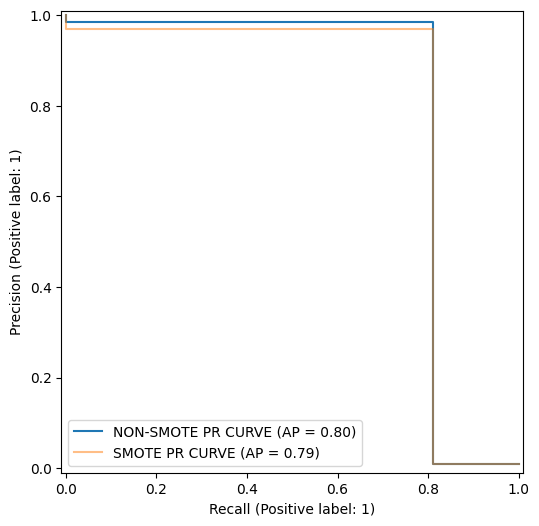

In [104]:
# PLotting for NON-SMOTE first

fig, ax = plt.subplots(1,1, figsize=(12,6))

disp_1 = PrecisionRecallDisplay.from_predictions(
    y_test_new,
    rfr_custom,
    name='NON-SMOTE PR CURVE',
    ax=ax
)

disp_2 = PrecisionRecallDisplay.from_predictions(
    y_test_new,
    custom_pred,
    name='SMOTE PR CURVE',
    ax=ax,
    alpha=0.5
    
)
    


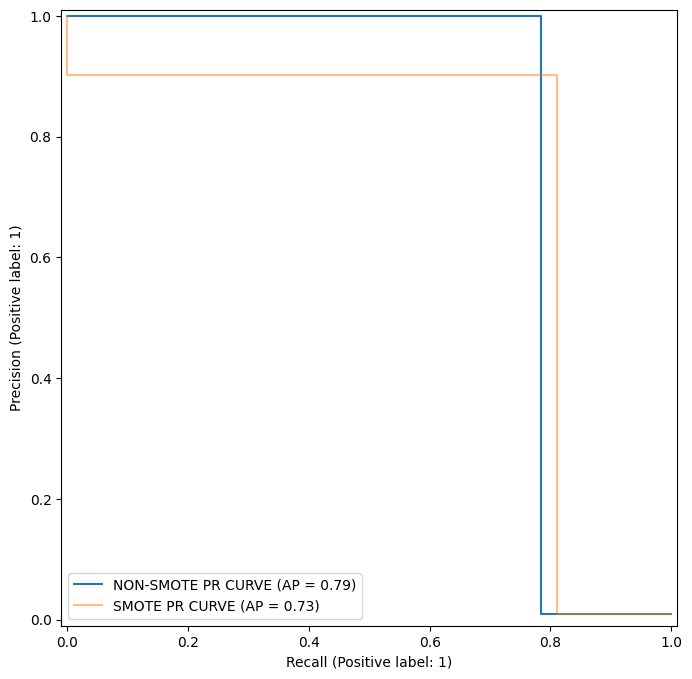

In [105]:
# PLotting for NON-SMOTE first

fig, ax = plt.subplots(1,1, figsize=(12,8))

disp_1 = PrecisionRecallDisplay.from_predictions(
    y_test_new,
    predict_rfr,
    name='NON-SMOTE PR CURVE',
    ax=ax
)

disp_2 = PrecisionRecallDisplay.from_predictions(
    y_test_new,
    smote_predict,
    name='SMOTE PR CURVE',
    ax=ax,
    alpha=0.5
    
)
    


In [106]:
smote_pipeline.named_steps['model'].feature_importances_

array([0.0446726 , 0.09287902, 0.03272914, 0.02003088, 0.18967457,
       0.04612638, 0.12315768, 0.31046441, 0.02792884, 0.11233648])

In [107]:
rfr.feature_importances_

array([0.04127995, 0.11579483, 0.03665693, 0.01581409, 0.19147599,
       0.0631949 , 0.11369335, 0.30753744, 0.02745344, 0.0870991 ])

# Since both Models look the exact same, we will look deeper and take a look at how confident the Models were.

# We will now look at the log loss. The log loss penelizes being 'confident and wrong'. If SMOTE made model more ocnfident on its correct guesses, it is the better model regardless of the same F1 Score as NON-SMOTE.

In [108]:
from sklearn.metrics import log_loss, brier_score_loss

# Calculate the Log-Loss
base_log = log_loss(y_test_new, rfr_probas)
smote_log = log_loss(y_test_new, smote_new_probas)

# Calculating the Brier Loss:
# This measure how close the predicted probabilities are to the actual outcomes.
# Essentialy the "Mean Squared Error" for probabilities. 
# A Lower Brier Score means a more well-calibrated model
base_brier = brier_score_loss(y_test_new, rfr_probas)
smote_brier = brier_score_loss(y_test_new, smote_new_probas)

In [109]:
# Printing all of the scores at once
print(f'BASE BRIER: {base_brier}')
print(f'SMOTE BRIER: {smote_brier}')
print(f'BASE LOG: {base_log}')
print(f'SMOTE LOG: {smote_log}')

BASE BRIER: 0.0019683000376931777
SMOTE BRIER: 0.0029306696821208697
BASE LOG: 0.04031070355108308
SMOTE LOG: 0.0287862037131013


# Plotting ROC curves for both models

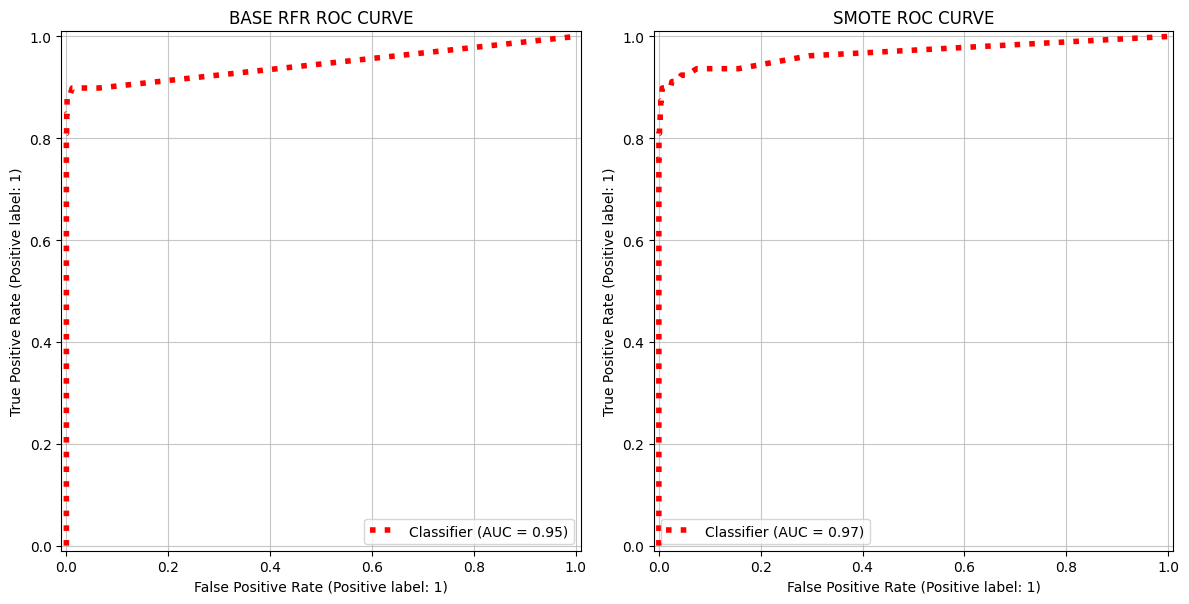

In [110]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

fig, ax = plt.subplots(1,2, figsize=(12,6))

# Do it for the Base Model first
base_disp = RocCurveDisplay.from_predictions(
    y_test_new,
    rfr_probas,
    ax=ax[0],
    linewidth=4,
    linestyle=':',
    color='red',
)

# Now do it for the SMOTE Model
smote_disp = RocCurveDisplay.from_predictions(
    y_test_new,
    smote_probas,
    ax=ax[1],
    linewidth=4,
    linestyle=':',
    color='red',
)

# Set the titles, and Format the plots
ax[0].set_title('BASE RFR ROC CURVE')
ax[0].grid(True, alpha=0.7)
ax[1].set_title('SMOTE ROC CURVE')
ax[1].grid(True, alpha=0.7)

plt.legend()
plt.tight_layout()
plt.show()



In [111]:
rfr_probas


array([0., 0., 0., ..., 0., 0., 0.])

In [112]:
smote_probas

array([0., 0., 0., ..., 0., 0., 0.])

# Now we are going to Calculate the Lift Charts, Using our own Custom Function

In [113]:
import numpy as np


# We first make a df with 2 columns: One for The actual target value, and one for the predicted target value
results = pd.DataFrame({'actual': y_test_new, 'prob': smote_probas})

# Sort by Probability of Fraud HIGH TO LOW
results = results.sort_values(by='prob', ascending=False)

# Create 10 Deciles
results['deciles'] = pd.qcut(results['prob'].rank(method='first'), 10, labels=range(10, 0, -1))

# Calculate the Lift per DECILE
baseline_rate = results['actual'].mean()
lift_table = results.groupby('deciles')['actual'].mean() / baseline_rate

/tmp/ipykernel_55/3986284565.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lift_table = results.groupby('deciles')['actual'].mean() / baseline_rate


In [114]:
lift_table

deciles
10    0.000000
9     0.000000
8     0.000000
7     0.253133
6     0.000000
5     0.000000
4     0.126566
3     0.253133
2     0.000000
1     9.365912
Name: actual, dtype: float64

<Axes: xlabel='deciles'>

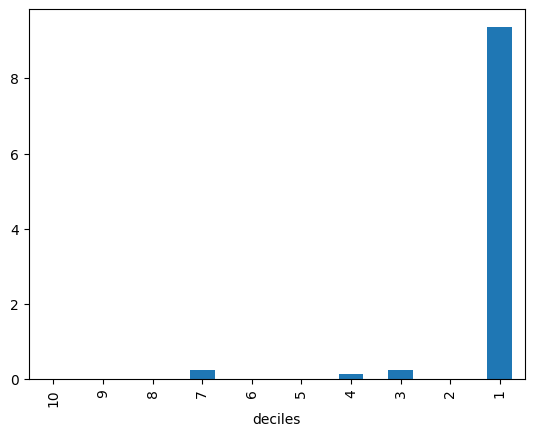

In [115]:
lift_table.plot(kind='bar')

In [116]:
baseline_rate

np.float64(0.009925870084181429)

In [117]:
results

,actual,prob,deciles
39418,1,1.0,1
39774,1,1.0,1
39593,1,1.0,1
39785,1,1.0,1
39702,1,1.0,1
...,...,...,...
4437,0,0.0,4
25682,0,0.0,4
19218,0,0.0,4
14482,0,0.0,4


In [118]:
results

,actual,prob,deciles
39418,1,1.0,1
39774,1,1.0,1
39593,1,1.0,1
39785,1,1.0,1
39702,1,1.0,1
...,...,...,...
4437,0,0.0,4
25682,0,0.0,4
19218,0,0.0,4
14482,0,0.0,4


In [119]:
rfr_probas

array([0., 0., 0., ..., 0., 0., 0.])

In [120]:
# Make the custom function
def plot_lift_curve(y_true, y_probs, title='Lift Curve'):
     # Create DF and sort
    df = pd.DataFrame({'actual': y_true, 'prob': y_probs})
    df = df.sort_values(by='prob', ascending=False).reset_index(drop=True)

    # Calculate the baseline rate
    baseline = df['actual'].mean()

    # We divide into 10 deciles (bins)
    # We use np.array_split to handle cases where data isnt perfectly divisible by 10
    chunks = np.array_split(df,10)
    # List for storing all of the Lift charts for each decile
    lifts=[]
    # Calculate num of bins
    deciles = list(range(1,11))

    for chunk in chunks:
        lift = chunk['actual'].mean() / baseline
        lifts.append(lift)


    # plotting
    plt.figure(figsize=(8,6))
    plt.plot(deciles, lifts, marker='o', linestyle='-', color='red', label='Model Lift')
    plt.axhline(y=1, color='black', linestyle='--', label='BaseLine (Random')


    
    plt.xlabel('Deciles (top 10% to bottom 10%)')
    plt.ylabel('Lift')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


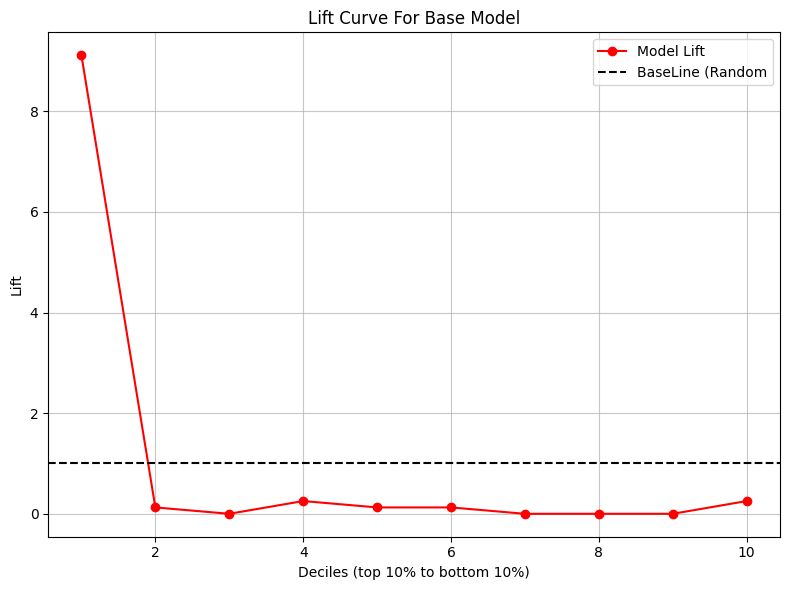

In [121]:
plot_lift_curve(y_test_new, rfr_probas, title='Lift Curve For Base Model')

Now we will plot Lift Curve for the SMOTE Model

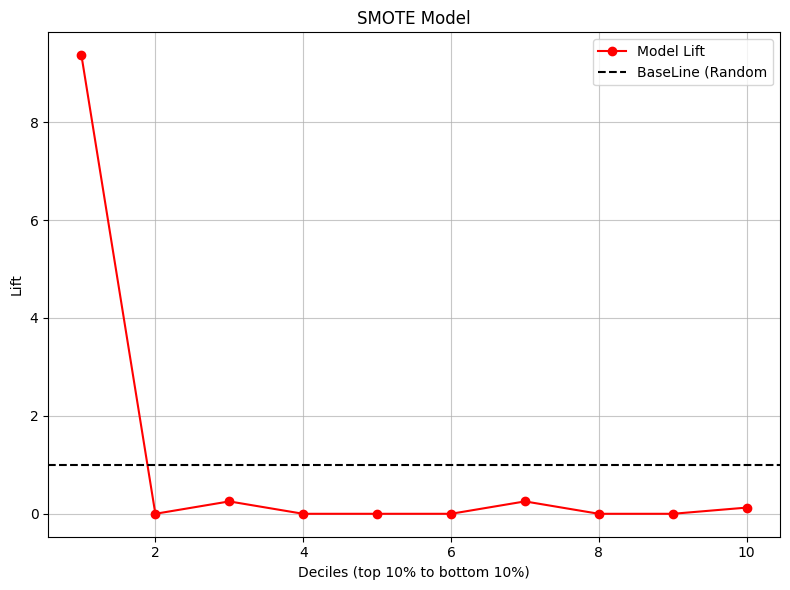

In [122]:
plot_lift_curve(y_test_new, smote_probas, title='SMOTE Model')

In [123]:
rfr

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

# Plot both of them side by side

In [124]:
# Make the custom function
def plot_lift_curve_both(y_true, y_probs1, y_probs2, num_ax, title1, title2):
     # Create DF and sort
    df1 = pd.DataFrame({'actual': y_true, 'prob': y_probs1})
    df1 = df1.sort_values(by='prob', ascending=False).reset_index(drop=True)

    df2 = pd.DataFrame({'actual': y_true, 'prob': y_probs2})
    df2 = df2.sort_values(by='prob', ascending=False).reset_index(drop=True)

    # Calculate the baseline rate
    # These contain the percentage of fraud in the dataset
    # Lift is a measure of Relative Importance over this baseline: This is the denominator
    baseline1 = df1['actual'].mean()
    baseline2 = df2['actual'].mean()

    # We divide into 10 deciles (bins)
    # We use np.array_split to handle cases where data isnt perfectly divisible by 10
    # We want to bin the data so we can see how Model's condifidence decays as we move from high-confidence to low-confidence
    chunks1 = np.array_split(df1,10)
    chunks2 = np.array_split(df2,10)

    # List for storing all of the Lift charts for each decile
    lifts1=[]
    lifts2=[]

    # Calculate num of bins
    deciles = list(range(1,11))

    # In these 2 loops, we calculate the LIFT Scores:
    #         The Lift Score Formula is 
    #
    #              Fraud in this specific Chunk
    #       Lift = --------------------------------
    #              Fraud Density in whole Dataset
    #
    #
    # Example: if total dataset is only 1% fraud, (Baseline = 0.01), But first Chunk (top 10%) contains 10% fraud, (Chunk mean = 0.10)
    # Result = 0.10/0.01 = 10.0
    #
    # What this value means: This value of 10 tells us that 'In this specific slice of data, my model is 10 times better at detecting fraud than a random guess'
    for chunk in chunks1:
        lift1 = chunk['actual'].mean() / baseline1
        lifts1.append(lift1)
        
    for chunk in chunks2:
        lift1 = chunk['actual'].mean() / baseline2
        lifts2.append(lift1)


    # plotting
    fig, ax = plt.subplots(1, num_ax, figsize=(12,4))
    ax[0].plot(deciles, lifts1, marker='o', linestyle='-', color='red', label='Model Lift')
    ax[0].axhline(y=1, color='black', linestyle='--', label='BaseLine (Random')
    ax[0].set_title(title1)

    ax[1].plot(deciles, lifts2, marker='o', linestyle='-', color='red', label='Model Lift')
    ax[1].axhline(y=1, color='black', linestyle='--', label='BaseLine (Random')
    ax[1].set_title(title2)


    
    ax[0].set_xlabel('Deciles (top 10% to bottom 10%)')
    ax[1].set_xlabel('Deciles (top 10% to bottom 10%)')

    ax[0].set_ylabel('Lift')
    ax[0].legend()
    ax[1].legend()
    ax[0].grid(True, alpha=0.7)
    ax[1].grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Summary of the Results, What the plot tells you:
    #    If value > 1: Model is finding more fraud than a random guess in that chunk. This is 'Positive Lift'
    #    If value = 1: Model is performing exactly like a random guess
    #    If value < 1: Model is finding less fraud than a random guess, This is good for bottom deciles, 
    #                                                                       as it means it correctly identified 'Safe' transactions.

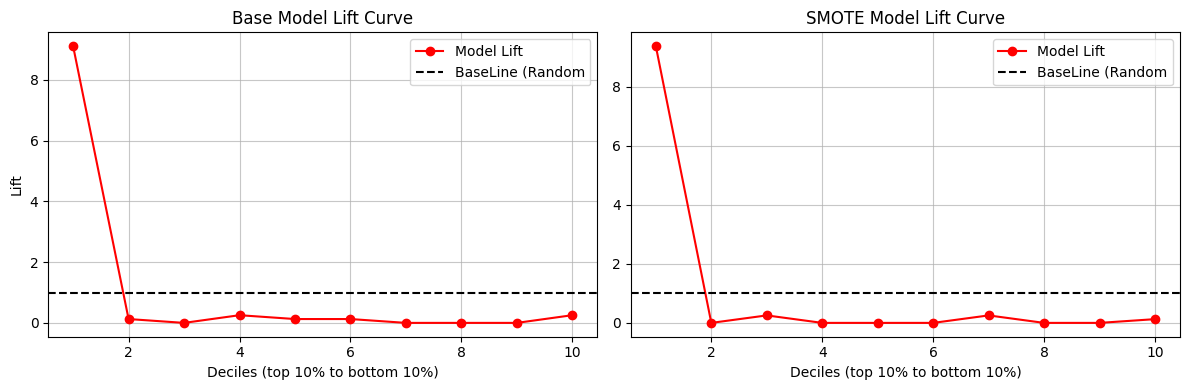

In [125]:
plot_lift_curve_both(y_test_new, rfr_probas, smote_probas, 2, title1='Base Model Lift Curve', title2='SMOTE Model Lift Curve')


In [126]:
rfr_probas

array([0., 0., 0., ..., 0., 0., 0.])

# The next step, Calibration:
# Even though, looking at out Lift charts, the models both seem really good, they are only ranked on how they rank an observation, rather than measuring the accuracy of the Models probability scores (Calibration). 
# A model can perfectly rank Credit Card Transactions from most Fraud to least Fraud, yet still provide probability scores that are far from the true, actual scores. 
# Lift tells you what to look at first (The top decile)
# Calibration Tells you how much you can trust the number your Model just gave you.

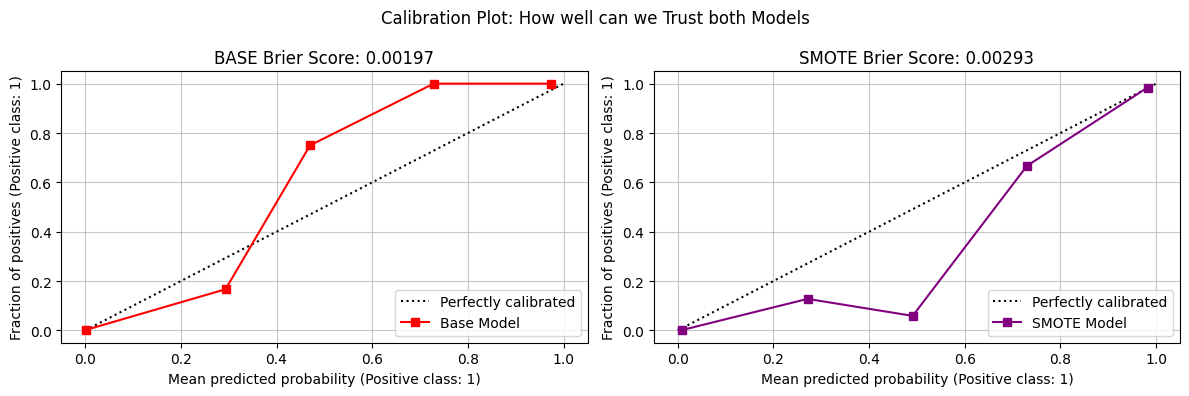

In [127]:
from sklearn.calibration import CalibrationDisplay


# Making two axes to plot both Models side by side
fig, ax = plt.subplots(1,2, figsize=(12,4))

# Potting the Base Model First
# .from_predictions always uses the predicted probs
CalibrationDisplay.from_predictions(y_test_new, rfr_probas, ax=ax[0], name='Base Model', color='red')
CalibrationDisplay.from_predictions(y_test_new, smote_probas, ax=ax[1], name='SMOTE Model', color='purple')

# Adding title 
fig.suptitle('Calibration Plot: How well can we Trust both Models')
ax[0].grid(True, alpha=0.7)
ax[1].grid(True, alpha=0.7)


# We will also be adding a seperate title for each of the Models for the Briar Score.
# The Briar score is basically a score summarizing hwo well the model calibrates: A score of 0 indicates a perfect model, while a score of 0.25 
#    indicates a Model that is just guessing at random. 

base_briar = brier_score_loss(y_test_new, rfr_probas)
smote_briar = brier_score_loss(y_test_new, smote_probas)

# ADD to ax titles
ax[0].set_title(f'BASE Brier Score: {base_briar:.5f}')
ax[1].set_title(f'SMOTE Brier Score: {smote_briar:.5f}')


plt.tight_layout()
plt.show()

# Why the Non_SMOTE Model won:
# In highly unbalanced datasets like this credit card fraud one, the original distribution carrier vital information. By using SMOTE, we overloaded the model with so much synthetic data, that we distrupted the 'Natural Frequency' of the data. The Non-SMOTE Model (especially due to using Near Miss and Select K Best), respected the rarity of Fraud. It actually learned the 'Signal' without the synthetic 'Noise'.
# This makes the Non-SMOTE Model a much more reliable Model when given financial decisions.

In [128]:
rfr.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

# Now we will fine tune the model:

In [129]:
from sklearn.model_selection import RandomizedSearchCV, cross_validate

grid = {
    'max_depth': [2,3,5,7,None],
    'min_samples_split': [2,3,4],
    'min_samples_leaf': [1,3,5,7],
    'max_leaf_nodes': [2,3,5, None]
}

inner = RandomizedSearchCV(
    rfr,
    n_iter=25,
    param_distributions=grid,
    cv=k,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)

outer = cross_validate(
    inner,
    X_train_new,
    y_train_new,
    cv=k,
    scoring='balanced_accuracy',
    return_train_score=True,
    return_estimator=True,
    n_jobs=-1,
    verbose=2
    
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END max_depth=None, max_leaf_nodes=3, min_samples_leaf=5, min_samples_split=4; total time=  17.3s
[CV] END max_depth=None, max_leaf_nodes=3, min_samples_leaf=5, min_samples_split=4; total time=  17.9s
[CV] END max_depth=None, max_leaf_nodes=3, min_samples_leaf=5, min_samples_split=4; total time=  17.9s
[CV] END max_depth=None, max_leaf_nodes=3, min_samples_leaf=5, min_samples_split=4; total time=  17.9s
[CV] END max_depth=3, max_leaf_nodes=2, min_samples_leaf=1, min_samples_split=3; total time=  13.3s
[CV] END max_depth=3, max_leaf_nodes=2, min_samples_leaf=1, min_samples_split=3; total time=  13.7s
[CV] END max_depth=3, max_leaf_nodes=2, min_samples_leaf=1, min_samples_split=3; total time=  14.1s
[CV] END max_depth=None, max_leaf_nodes=3, min_samples_leaf=5, min_samples_split=4; total time=  18.8s
[CV] END max_depth=3, max_leaf_nodes=2, min_samples_leaf=1, min_samples_split=3; total time=  13.6s
[CV] END max_depth=3, m

[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 12.9min finished


In [130]:
# Find the best parameters
for i, est in enumerate(outer['estimator']):
    print(f'Fold {i}: Best Params: {est.best_params_}')

Fold 0: Best Params: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': 5, 'max_depth': 3}
Fold 1: Best Params: {'min_samples_split': 3, 'min_samples_leaf': 3, 'max_leaf_nodes': 5, 'max_depth': 3}
Fold 2: Best Params: {'min_samples_split': 2, 'min_samples_leaf': 3, 'max_leaf_nodes': 5, 'max_depth': 3}
Fold 3: Best Params: {'min_samples_split': 3, 'min_samples_leaf': 7, 'max_leaf_nodes': 5, 'max_depth': 7}
Fold 4: Best Params: {'min_samples_split': 2, 'min_samples_leaf': 3, 'max_leaf_nodes': 5, 'max_depth': 5}


In [131]:
rfr.min_samples_leaf = 7
rfr.max_leaf_nodes = 5
rfr.min_samples_split = 2

In [132]:
from sklearn.model_selection import RandomizedSearchCV

new_grid = {
    'max_depth': [2,3,4,5,6,7]
}

search1 = RandomizedSearchCV(
    rfr,
    param_distributions=grid,
    n_iter=20,
    cv=k,
    scoring='average_precision',
    n_jobs=-1,
    verbose=2
)

outer1 = cross_validate(
    search1,
    X_train_new,
    y_train_new,
    cv=k,
    scoring='average_precision',
    return_estimator=True,
    return_train_score=True,
    n_jobs=-1,
    verbose=2
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.



[CV] END max_depth=None, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=2; total time=  22.3s
[CV] END max_depth=None, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=2; total time=  22.6s
[CV] END max_depth=None, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=2; total time=  22.6s
[CV] END max_depth=None, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=2; total time=  21.9s
[CV] END max_depth=None, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=2; total time=  22.5s
[CV] END max_depth=3, max_leaf_nodes=None, min_samples_leaf=3, min_samples_split=2; total time=  19.1s
[CV] END max_depth=3, max_leaf_nodes=None, min_samples_leaf=3, min_samples_split=2; total time=  19.6s
[CV] END max_depth=3, max_leaf_nodes=None, min_samples_leaf=3, min_samples_split=2; total time=  18.9s
[CV] END max_depth=3, max_leaf_nodes=None, min_samples_leaf=3, min_samples_split=2; total time=  19.0s
[CV] END max_depth=3, max_leaf_nodes=None, min_samples_leaf=3, min_sampl

[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 11.0min finished


In [133]:
for i, ex in enumerate(outer1['estimator']):
    print(f'Fold {i}: Best Params: {ex.best_params_}')

Fold 0: Best Params: {'min_samples_split': 4, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_depth': None}
Fold 1: Best Params: {'min_samples_split': 2, 'min_samples_leaf': 3, 'max_leaf_nodes': None, 'max_depth': None}
Fold 2: Best Params: {'min_samples_split': 4, 'min_samples_leaf': 3, 'max_leaf_nodes': None, 'max_depth': 7}
Fold 3: Best Params: {'min_samples_split': 3, 'min_samples_leaf': 5, 'max_leaf_nodes': None, 'max_depth': None}
Fold 4: Best Params: {'min_samples_split': 4, 'min_samples_leaf': 5, 'max_leaf_nodes': None, 'max_depth': None}


In [134]:
rfr.max_depth = 7

In [135]:
outer1['test_score']

array([0.91160023, 0.91062098, 0.83833515, 0.84693168, 0.90007655])

In [136]:
outer1['train_score']

array([0.99998432, 0.99082121, 0.9846987 , 0.98815181, 0.98461966])

# Now we have our final model: SO we will  perform a final Test Data check

In [137]:
# Get the predictions of the Minority class 
final_probs = rfr.predict_proba(X_test_new)[:,1]

In [138]:
from sklearn.metrics import average_precision_score
# Final AP score
final_ap = average_precision_score(y_test_new, final_probs)
# Final Brier score
final_brier = brier_score_loss(y_test_new, final_probs)

# printing them all out
print('--------RESULTS--------')
print(f'Final AP score: {final_ap:.5f}')
print(f'Final Brier Score: {final_brier:.5f}')

--------RESULTS--------
Final AP score: 0.88444
Final Brier Score: 0.00197


# If metrics such as Average Precision (AP) tell you how well the Model is doing, SHAP tells you why it is doing it. In fields such as Finance or Medical, 'Just trust me' doesnt cut it, you need to be able to explain why your model did something, and what triggered the response.
# SHAP (Shapley Additive Explanations), calculates the 'Shapley Value' for all Features by testing how the prediction changes whther that specific feature is present or not, across all combiantions of features.
# Although this sounds amazing, it is expensive if calculated over thoousands of rows. That is why we are using TreeExplainer, a SHAP optimized for tree-based models.

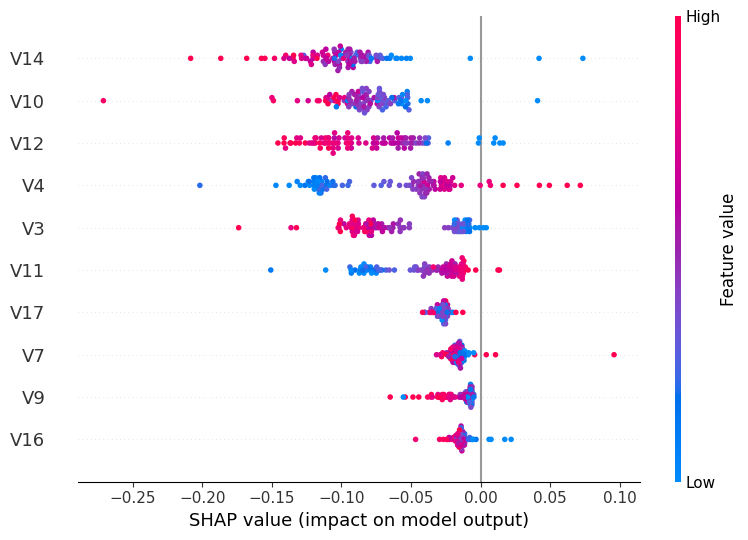

In [140]:
# Plot Global Importance
# For binary classification, shap_values is always a list [values_for_0, values_for_1]
# We usually look at index 1 (Fraud)
shap.summary_plot(shap_values[:,:,1], X_sample)

# By looking at the SHAP plot, we can see that the number one feature in the data was v14, since it was at the top of the list. Since we can see a cluster of blue dots on the right of the X axis (positive axis), it means, 'When V14 is Low(Blue), the probability of Fraud goes up. 
# If you see red dots on the Negative (left) side, It means 'When x is high (red), Model thinks that the transaction is SAFE.
# If the dots are wide and spread apart, the features has a massive impact. If they are all bunched near zero, the feature is barely moving the needle. A dot way out at +4 score can change the outcome of the prediciton easily, but if all of the scores are bunched near zero, the feature is 'quiet', even if Value of feature changes from red to blue (high to low), the models confidence barely moves.
# Plot also tells us about Global vs Local feature importances: If a Feature is very high up on the list, that is the 'average' of all of those dots, in other words, over all instances in the data, this feature did the most amount of work overall. If a Feature is very low on the list but has a massive spread, that means that The feature is not always useful, but when it is, it is a huge dealbreaker.

In [141]:
shap_values

array([[[ 0.09220434, -0.09220434],
        [ 0.12313138, -0.12313138],
        [ 0.01247456, -0.01247456],
        ...,
        [ 0.07035795, -0.07035795],
        [ 0.00337796, -0.00337796],
        [ 0.02381891, -0.02381891]],

       [[ 0.01212429, -0.01212429],
        [ 0.04818917, -0.04818917],
        [ 0.02110837, -0.02110837],
        ...,
        [ 0.10512557, -0.10512557],
        [ 0.01704975, -0.01704975],
        [ 0.03163811, -0.03163811]],

       [[ 0.00101797, -0.00101797],
        [ 0.03948628, -0.03948628],
        [-0.09577092,  0.09577092],
        ...,
        [ 0.09853158, -0.09853158],
        [ 0.01461694, -0.01461694],
        [ 0.0319177 , -0.0319177 ]],

       ...,

       [[ 0.091431  , -0.091431  ],
        [ 0.07668138, -0.07668138],
        [ 0.01612675, -0.01612675],
        ...,
        [ 0.11067288, -0.11067288],
        [ 0.01284139, -0.01284139],
        [ 0.02612333, -0.02612333]],

       [[ 0.07910436, -0.07910436],
        [ 0.12387792, -0.12

# Now we are going to be using CalibrationClassifierCV to improve the Calibration of our RFR Base Model. 

In [142]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import RepeatedStratifiedKFold

"""
    We use RepeatedStratifiedKFold over normal StratifiedKFold because it makes sure that the model did not just get lucky with a 
    draw of the data. It runs the standard StratifiedKFold function n_repeats times, each with a differetn randomization, providing a more robust
    estimate of Models performance. This also helos reduce the Variance in the performance metric.


"""


new_k = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

calibrated_rfr = CalibratedClassifierCV(rfr, cv=new_k, method='isotonic')

# Fit the model using the Training data
calibrated_rfr.fit(X_train_new, y_train_new)

CalibratedClassifierCV(cv=RepeatedStratifiedKFold(n_repeats=10, n_splits=5, random_state=42),
                       estimator=RandomForestClassifier(class_weight='balanced',
                                                        max_depth=7,
                                                        max_leaf_nodes=5,
                                                        min_samples_leaf=7,
                                                        n_jobs=-1,
                                                        random_state=42),
                       method='isotonic')

# Now what exactly happens when we run CalibratedClassifierCV on data?
# It split data into K folds, and for each fold, trained a fresh RFR model on it. It then took the RFR and on the left out data, asked it ' What is the probability of fraud here?'. It then took these probs and the actual labels and performed a mathematical function (Isotonic or Sigmoid), to transalate into 'Calibrated probability'. It didnt just keep one model, it kept all of them, so the next time you call predict_proba(), it asks all of the models for their opinion and averages their calibrated scores.
# The CalibratedClassifier object now acts as a container, so you can reach inside to see the 'mini-models' created. The Key Attributes stored are .calibrated_classifiers_ (a list of all of the fitted models, if you had cv=5 and n_repeats=3, you would have 15 models), and .classes_, which stores the classes, in our case, 0 and 1.

In [143]:
# How to access the individual models
# See the first model created by CalibratedClassifier
# NOTE: This return the place where the model is stroed in computer, not the actual model itself. If we want to access model, we will need to use .estimator
first = calibrated_rfr.calibrated_classifiers_[0]

# See the actual model
first_rfr = first.estimator

# See the specific Calibration mapping (Sigmoid'/Isotonic) used in this model
mapping = first.calibrators[0]

In [144]:
first_rfr

RandomForestClassifier(class_weight='balanced', max_depth=7, max_leaf_nodes=5,
                       min_samples_leaf=7, n_jobs=-1, random_state=42)

In [145]:
mapping

IsotonicRegression(out_of_bounds='clip')

# Now we will use the final Calibrated Model and compare it to the Base RFR models with multiple metrics to see if the new Calibrated model has improved.

In [146]:
calibrated_probs = calibrated_rfr.predict_proba(X_test_new)
calibrated_pred  = calibrated_rfr.predict(X_test_new)

In [147]:
calibrated_probs = calibrated_probs[:,1]

In [148]:
from sklearn.metrics import fbeta_score
# Compute Brier scores


calibrated_brier = brier_score_loss(y_test_new, calibrated_probs)
calibrated_f1 = f1_score(y_test_new, calibrated_pred)
calibrated_f2 = fbeta_score(y_test_new, calibrated_pred, average='weighted', beta=2)


print(f'Original Brier Scores: {base_brier}')
print(f'Calibrated Brier Scores: {calibrated_brier}')
print(f'Original F1 Score: {f1_score(y_test_new, predict_rfr)}')
print(f'Calibrated F1 Score: {calibrated_f1}')
print(f"Original F2 score: {fbeta_score(y_test_new, predict_rfr, average='weighted', beta=2)}")
print(f'Calibrated F2 score: {calibrated_f2}')

Original Brier Scores: 0.0019683000376931777
Calibrated Brier Scores: 0.002348784430350883
Original F1 Score: 0.8794326241134752
Calibrated F1 Score: 0.8648648648648649
Original F2 score: 0.9977873886368561
Calibrated F2 score: 0.9974449194448137


In [149]:
predict_rfr

array([0, 0, 0, ..., 0, 0, 0])

In [150]:
rfr_custom

array([0, 0, 0, ..., 0, 0, 0])

# Now we are going to plot the CalibrationDisplay for both the base and Calibrated Models.

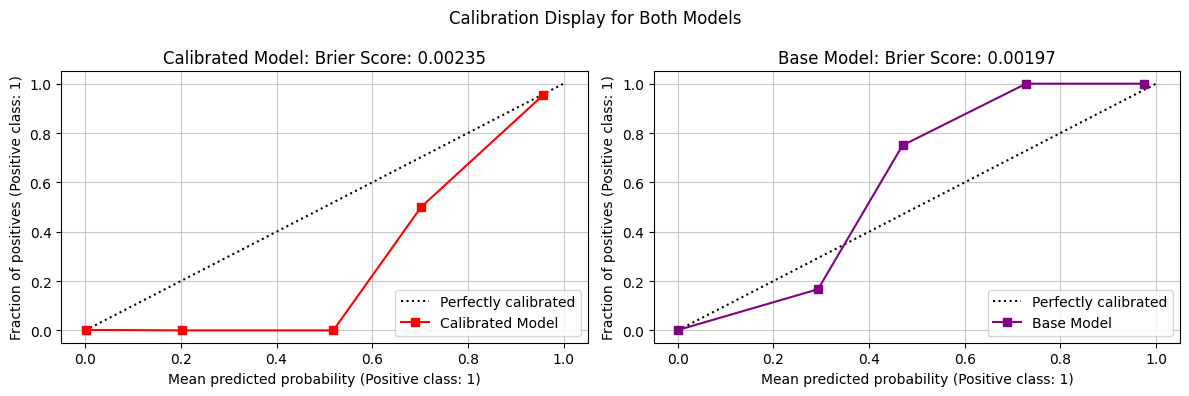

In [151]:
fig, ax = plt.subplots(1,2, figsize=(12,4))


# Plot for the Calibrated Model
CalibrationDisplay.from_predictions(y_test_new, calibrated_probs, ax=ax[0], name='Calibrated Model', color='red')
# Plot for the Base Model
CalibrationDisplay.from_predictions(y_test_new, rfr_probas, ax=ax[1], name='Base Model', color='purple')

# Displaying settings
fig.suptitle('Calibration Display for Both Models')
ax[0].set_title(f'Calibrated Model: Brier Score: {calibrated_brier:.5f}')
ax[1].set_title(f'Base Model: Brier Score: {base_brier:.5f}')
plt.tight_layout()
ax[0].grid(True, alpha=0.7)
ax[1].grid(True, alpha=0.7)
plt.show()

# Wait, but looking at this plot tells us that the new, Calibrated Model is worse than the base Model, here are a few reasons why that may be:
### Since we used Isotonic Regression, we used an extremely powerful but also greedy model. Isotonic tries to fit a stair case pattern to data , so if validation-set has very few fraud cases in certain probabilities, the Isotonic model hallucinates on the noise, creating a jagged effect that looks worse than the original RF Model.
### Since we arent using our tuned RF model, these new models created by CalibratedClassifierCV might be too weak to understand data
### Calibration plots work by binning predictions into groups (eg, 0-10%, 10-20%, etc). In a Fraud dataset, a bin like 40-50% probability might on;y have 2-3 fraud cases, and if even one of these is a lucky catch, the 'observed frequency of that bin jumps by 100% making model look worse than it actually is, when in realilty it doesnt have eneough bins.
# Now we have 3 steps to do:
### 1. Check Brier Score: Even if plot looks worse, if Brier score better than base model, it means Calibrated Model is working
### 2. Isotonic vs Sigmoid: If Isotonic looks like a mess, Pros switch over to method='sigmoid'. Platt Scaling (Sigmoid) is much more conservative, forcing a smooth curve, and is far less likely to overfit.
### 3. AP Score: Check the AP score of Calibrated Model. If it dropped after Calibration, it means the 'averaging effect' of CV is hurting models ability to find fraud. So in this case, Calibration is not worth it.

In [152]:
# We already checked Brier score, and saw that it was worse with Calibrated Model, so now we move on to check with method='sigmoid'
sigmoid_calibrated = CalibratedClassifierCV(rfr, cv=new_k, method='sigmoid')
sigmoid_calibrated.fit(X_train_new, y_train_new)


[CV] END max_depth=3, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=2; total time=  19.0s
[CV] END max_depth=3, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=2; total time=  19.5s
[CV] END max_depth=3, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=2; total time=  19.4s
[CV] END max_depth=3, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=2; total time=  19.0s
[CV] END max_depth=None, max_leaf_nodes=3, min_samples_leaf=5, min_samples_split=4; total time=  18.5s
[CV] END max_depth=None, max_leaf_nodes=3, min_samples_leaf=5, min_samples_split=4; total time=  18.5s
[CV] END max_depth=None, max_leaf_nodes=3, min_samples_leaf=5, min_samples_split=4; total time=  18.2s
[CV] END max_depth=None, max_leaf_nodes=3, min_samples_leaf=5, min_samples_split=4; total time=  18.0s
[CV] END max_depth=None, max_leaf_nodes=3, min_samples_leaf=5, min_samples_split=4; total time=  18.6s
[CV] END max_depth=3, max_leaf_nodes=None, min_samples_leaf=7, min_samples_split=3; 

CalibratedClassifierCV(cv=RepeatedStratifiedKFold(n_repeats=10, n_splits=5, random_state=42),
                       estimator=RandomForestClassifier(class_weight='balanced',
                                                        max_depth=7,
                                                        max_leaf_nodes=5,
                                                        min_samples_leaf=7,
                                                        n_jobs=-1,
                                                        random_state=42))

In [153]:
sigmoid_pred = sigmoid_calibrated.predict(X_test_new)
sigmoid_probs = sigmoid_calibrated.predict_proba(X_test_new)


[CV] END max_depth=None, max_leaf_nodes=2, min_samples_leaf=3, min_samples_split=2; total time=  13.6s
[CV] END max_depth=None, max_leaf_nodes=2, min_samples_leaf=3, min_samples_split=2; total time=  13.7s
[CV] END max_depth=None, max_leaf_nodes=2, min_samples_leaf=3, min_samples_split=2; total time=  13.8s
[CV] END max_depth=7, max_leaf_nodes=5, min_samples_leaf=3, min_samples_split=4; total time=  23.2s
[CV] END max_depth=7, max_leaf_nodes=5, min_samples_leaf=3, min_samples_split=4; total time=  23.4s
[CV] END max_depth=7, max_leaf_nodes=5, min_samples_leaf=3, min_samples_split=4; total time=  22.7s
[CV] END max_depth=7, max_leaf_nodes=5, min_samples_leaf=3, min_samples_split=4; total time=  21.8s
[CV] END max_depth=7, max_leaf_nodes=5, min_samples_leaf=3, min_samples_split=4; total time=  22.7s
[CV] END max_depth=5, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=2; total time=  22.7s
[CV] END max_depth=5, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=2; total tim

In [154]:
# We take only the Fraud Predictions in the Probability Values
sigmoid_probs=sigmoid_probs[:,1]

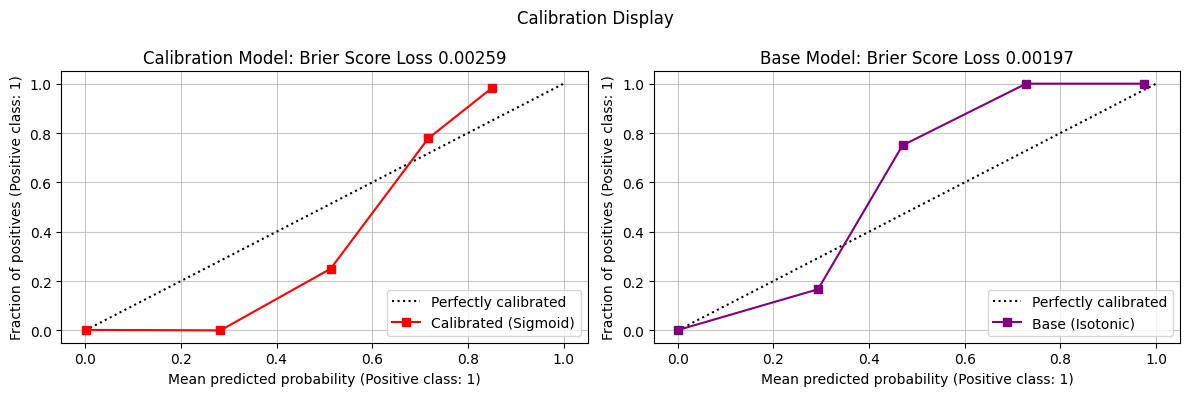

In [155]:
fig, ax = plt.subplots(1,2 ,figsize=(12,4))


# Use method='sigmoid' for CalibrationDisplay
CalibrationDisplay.from_predictions(y_test_new, sigmoid_probs, ax=ax[0],name='Calibrated (Sigmoid)', color='red')
CalibrationDisplay.from_predictions(y_test_new, rfr_probas, ax=ax[1], name='Base (Isotonic)', color='purple')


# Adding the Brier scores to make it easier to Evaluate Models
sigmoid_brier = brier_score_loss(y_test_new, sigmoid_probs)




fig.suptitle('Calibration Display')
ax[0].set_title(f'Calibration Model: Brier Score Loss {sigmoid_brier:.5f}')
ax[1].set_title(f'Base Model: Brier Score Loss {base_brier:.5f}')
ax[0].grid(True, alpha=0.7)
ax[1].grid(True, alpha=0.7)
plt.tight_layout()
plt.show()

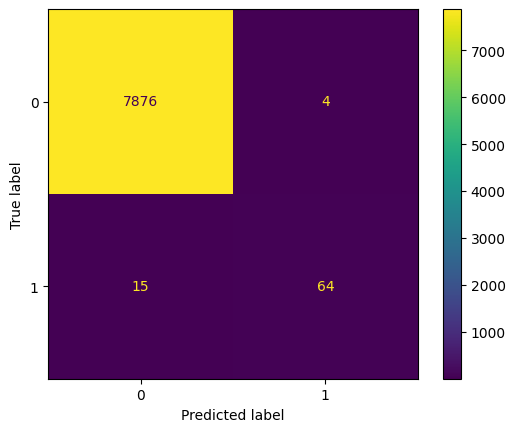

In [156]:
# Findign out what Claibration Sigmoid model is struggling on
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(y_test_new, sigmoid_pred)
plt.show()


[CV] END max_depth=5, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=3; total time=  23.1s
[CV] END max_depth=5, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=3; total time=  22.2s
[CV] END max_depth=5, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=3; total time=  22.7s
[CV] END max_depth=5, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=3; total time=  22.4s
[CV] END max_depth=5, max_leaf_nodes=5, min_samples_leaf=7, min_samples_split=3; total time=  23.2s
[CV] END max_depth=7, max_leaf_nodes=None, min_samples_leaf=3, min_samples_split=3; total time=  36.6s
[CV] END max_depth=7, max_leaf_nodes=None, min_samples_leaf=3, min_samples_split=3; total time=  37.2s
[CV] END max_depth=7, max_leaf_nodes=None, min_samples_leaf=3, min_samples_split=3; total time=  35.5s
[CV] END max_depth=5, max_leaf_nodes=3, min_samples_leaf=1, min_samples_split=4; total time=  17.5s
[CV] END max_depth=7, max_leaf_nodes=None, min_samples_leaf=3, min_samples_split=3; total 

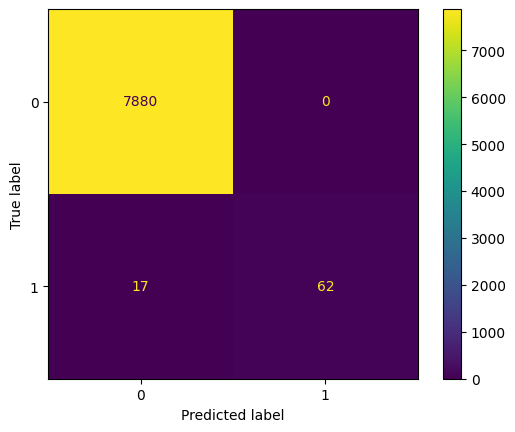


[CV] END max_depth=7, max_leaf_nodes=None, min_samples_leaf=7, min_samples_split=4; total time=   7.5s
[CV] END max_depth=7, max_leaf_nodes=None, min_samples_leaf=7, min_samples_split=4; total time=   6.6s
[CV] END max_depth=7, max_leaf_nodes=None, min_samples_leaf=7, min_samples_split=4; total time=   6.0s
[CV] END .................................................... total time= 3.0min


In [157]:
# Compare to Base Model

rfr_pred = rfr.predict(X_test_new)

disp = ConfusionMatrixDisplay.from_predictions(y_test_new, rfr_pred)
plt.show()

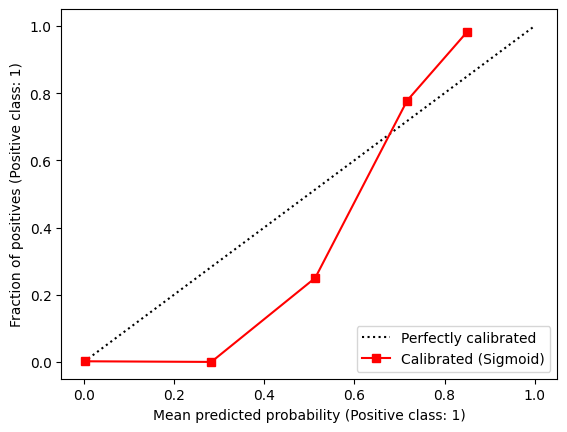

In [175]:
# Plotting Calibration Display again, but this time with strategy'quantile', instead of strategy='uniform'


CalibrationDisplay.from_predictions(y_test_new, sigmoid_probs,name='Calibrated (Sigmoid)', color='red', strategy='uniform')
plt.show()

In [179]:
# Computing the AP scores for the calubrated and Base Models to see if Calirbation helped at all
calibrated_ap = average_precision_score(y_test_new, calibrated_probs)
sigmoid_ap = average_precision_score(y_test_new, sigmoid_probs)

In [182]:
print(f'Calibrated Model AP Score: {calibrated_ap}')
print(f'Sigmoid Calibrated Model AP Score: {sigmoid_ap}')
print(f'Base AP Score: {average_precision_score(y_test_new, rfr_probas)}')

Calibrated Model AP Score: 0.8342950460624312
Sigmoid Calibrated Model AP Score: 0.830693707118518
Base AP Score: 0.8844394624851254


# Now, we have evaluated and came to the conclusion that the Base Model is the best model out of all the ones we have tried, so we will save it with joblib.

In [192]:
import joblib

# Save the model into a File called  'credit_card_fraud_model.pkl'
joblib.dump(rfr, 'credit_card_fraud_model.pkl')

['credit_card_fraud_model.pkl']

# In this project we have proven that the fancy Calibrated models dont always perform better than the normal models. In our case, it looks like the NearMiss and Feature selection techniques helped the original model way more than any fancy model architecture could. This proves that Good Data always beats Fancy Models.

In [206]:
# To check what the base model score is, we will make a new model and fit it to original data, before NearMiss 
new_rfr = RandomForestClassifier(random_state=42, class_weight='balanced').fit(X, Y)

In [219]:
X = X_train[: 39_000]
Y = y_train[:39_000]

In [210]:
new_X_test = X_test[:30_000]
new_y_test = y_test[: 30_000]

In [217]:
# Compute metrics such as AP, and F1

og_prob = new_rfr.predict_proba(new_X_test)[:,1]
og_pred = new_rfr.predict(new_X_test)

print(f'OG MODEl AP Score: {average_precision_score(new_y_test, og_prob)}')
print(f'OG MODEL F1 Score: {f1_score(new_y_test, og_pred)}')

OG MODEl AP Score: 0.001724314005053366
OG MODEL F1 Score: 0.0


# Even though Model was trained on random Subset, we can see how bad the model is on the og Data compared to the new, clean data.

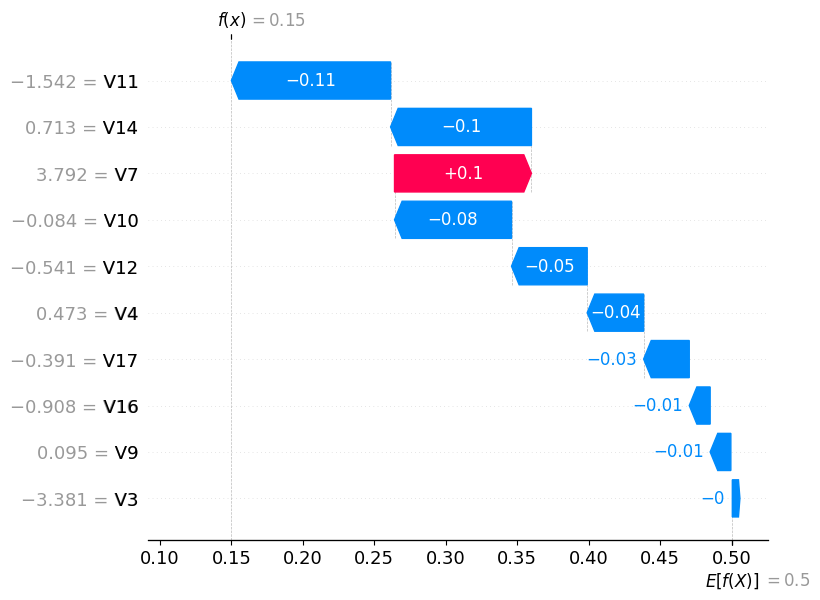

In [250]:
# We have to re instantiate thsi line of code, since we use dexplainer.shap_values() before, which returns a raw array, whe the Waterfall plot
# Requires us to use this
new_shap_values = explainer(X_sample)
shap.plots.waterfall(new_shap_values[2, :,1])